In [1]:
# copied from analyses/kw21_MDC_paper/MDC_simulation_updated.ipynb

import pandas as pd
import numpy as np
import sklearn.metrics as sk_metrics
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
import seaborn as sns
from sklearn.svm import SVR

import itertools, random

n = 10000


In [2]:
def regression(X, y, plot=False, debug=False):
    kfolds = KFold(n_splits=10, shuffle=True, random_state=42)
    y_pred_collected = []
    y_true_collected = []
    for train_indices, test_indices in kfolds.split(X):
        X_train, X_test = X[train_indices], X[test_indices]
        y_train, y_test = y[train_indices], y[test_indices]

        model = LinearRegression()
        #model = SVR(kernel="rbf", C=0.5)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        y_pred_collected.append(y_pred)
        y_true_collected.append(y_test)

    y_test, y_hat = np.concatenate(y_true_collected), np.concatenate(y_pred_collected)

    mse = sk_metrics.mean_squared_error(y_test, y_hat)
    r2 = sk_metrics.r2_score(y_test, y_hat)
    if debug:
        print("Regression results:")
        print(f"- MSE: {mse:.4f}")
        print(f"- R2: {r2:.4f}")

    return {
        'y_test': y_test,
        'y_hat': y_hat,
        'mse': mse,
        'r2': r2,
    }


def combine_regression_results(regression_results_list):
    y_test_combined = pd.DataFrame({f'y_test_{i}': res['y_test'] for i, res in enumerate(regression_results_list)})
    assert np.all(y_test_combined.var(axis=1) < 1e-6), "y_test should be the same across different regression results"
    y_test_avg = y_test_combined.mean(axis=1)
    y_hat_combined = pd.DataFrame({f'y_hat_{i}': res['y_hat'] for i, res in enumerate(regression_results_list)})
    y_hat_avg = y_hat_combined.mean(axis=1)
    mse = sk_metrics.mean_squared_error(y_test_avg, y_hat_avg)
    r2 = sk_metrics.r2_score(y_test_avg, y_hat_avg)
    return {
        'y_test': y_test_avg,
        'y_hat': y_hat_avg,
        'mse': mse,
        'r2': r2,
    }


def create_true_data(n=1000, sigma_c_sq=0.637, rho=0.0, seed=12):
    """
    Create latent cognition c and clean speech features X_true.

    rho controls how much of the speech-feature variance is due to stable
    non-cognitive influences rather than cognition:

        rho = 0.0  -> all feature variance is cognition-related
        rho = 1.0  -> no cognition-related feature variance

    The construction makes cognition drive a 1D signal in feature space, while
    the remaining feature variance comes from a stable speaker-specific
    non-cognitive component orthogonal to that cognition direction.
    """
    k = 10
    rng = np.random.default_rng(seed)

    # latent cognition
    c = rng.normal(0, np.sqrt(sigma_c_sq), n)

    # unit vector defining the cognition-related direction in feature space
    w = rng.normal(0, 1, k)
    w = w / np.linalg.norm(w)

    # cognition-related feature component:
    # each subject gets c_i projected along the same direction w
    X_cog = np.outer(c / np.sqrt(sigma_c_sq), w)

    # non-cognitive speaker-specific feature component
    Z = rng.normal(0, 1, (n, k))
    Z_row_sd = Z.std(axis=0, ddof=1).mean()
    if Z_row_sd > 0:
        Z = Z / Z_row_sd

    # mix the two sources
    X_true = np.sqrt(1 - rho) * X_cog + np.sqrt(rho) * Z

    return X_true, c, w


def create_speaker_feature_bias(n, k, sigma_beta_sq, seed=None):
    """Stable speaker-specific non-cognitive influence on the FEATURES.

    We draw one scalar speaker trait per subject and map it into feature space
    using a fixed loading vector with unit norm. The resulting nuisance term is
    constant across waves for a given subject, independent of X (and therefore
    of C) by construction, and has expected total variance sigma_beta_sq across
    the k-dimensional feature vector.

    If s_i ~ N(0, sigma_beta_sq) and ||g||=1, then the feature-side nuisance is
        B_i = s_i g,
    which is reused across waves and added before session-specific feature
    measurement noise.
    """
    rng = np.random.default_rng(seed)
    speaker_scores = rng.normal(0, np.sqrt(sigma_beta_sq), size=(n, 1))
    loadings = rng.normal(0, 1, size=(1, k))
    loadings = loadings / np.linalg.norm(loadings)
    return speaker_scores @ loadings


def create_X_obs(X, features_measurement_noise_variance):
    feature_measurement_noise = np.random.normal(
        0, np.sqrt(features_measurement_noise_variance), X.shape
    )
    X_obs = X + feature_measurement_noise
    return X_obs

def create_y(c, target_measurement_noise_variance):
    target_measurement_noise = np.random.normal(
        0, np.sqrt(target_measurement_noise_variance), len(c)
    )
    y = c + target_measurement_noise
    return y


def calculate_target_reliability(c, target_measurement_noise_variance):
    # sample reliability via test-retest correlation of two noisy observations of c
    y1 = create_y(c, target_measurement_noise_variance)
    y2 = create_y(c, target_measurement_noise_variance)
    sample_reliability = pearsonr(y1, y2).statistic
    return sample_reliability


def calculate_biomarker_reliability(y_hat1, y_hat2, debug=False):
    """Test-retest reliability of the speech biomarker."""
    sample_reliability = pearsonr(y_hat1, y_hat2).statistic
    if debug:
        print(f"Sample biomarker reliability: {sample_reliability:.4f} (Pearson r)")
    return sample_reliability



In [3]:
def calculate_mdc_from_two_waves(y_hat1, y_hat2, y_test1, y_test2, target_reliability, z=1.96):
    """
    Estimate MDC quantities from two waves of predictions.

    """
    # Latent cognitive variance from cross-wave covariance of observed targets
    var_c_hat = np.cov(y_test1, y_test2)[0, 1]
    var_y = np.mean([np.var(y_test1, ddof=1), np.var(y_test2, ddof=1)])

    # Observable estimator of lambda
    cov_yhat1_y1 = np.cov(y_hat1, y_test1)[0, 1]
    cov_yhat2_y2 = np.cov(y_hat2, y_test2)[0, 1]
    lambd = np.mean([cov_yhat1_y1, cov_yhat2_y2]) / var_c_hat

    delta_yhat = np.asarray(y_hat2) - np.asarray(y_hat1)
    var_delta_yhat = np.var(delta_yhat, ddof=1)
    sd_delta_yhat = np.sqrt(var_delta_yhat)

    sigma_epsilon_sq_hat = var_delta_yhat / 2.0
    sigma_epsilon_hat = np.sqrt(sigma_epsilon_sq_hat)

    mdc_prediction_space = z * sd_delta_yhat
    mdc_latent_space = mdc_prediction_space / np.abs(lambd) if lambd != 0 else np.nan
    mdc_cognitive = z * np.sqrt(2 * var_y * (1 - target_reliability))

    return {
        'cognitive_mdc': mdc_cognitive,
        'mdc_latent_space': mdc_latent_space,
        'mdc_prediction_space': mdc_prediction_space,
        'lambda': lambd,
        'var_c_hat': var_c_hat,
        'var_y': var_y,
        'var_delta_yhat': var_delta_yhat,
        'sd_delta_yhat': sd_delta_yhat,
        'sigma_epsilon_sq_hat': sigma_epsilon_sq_hat,
        'sigma_epsilon_hat': sigma_epsilon_hat,
    }



def run_simulation(target_measurement_noise_variance,
                   features_measurement_noise_variance,
                   rho,
                   mean_over_n_predictions=2):
    """
    Monte-Carlo simulation of the speech MDC

    The data-generating process is:
        Y_it = C_it + delta_it
        Xobs_it = X_i + B_i + eta_it

    where B_i is a time-invariant feature-side nuisance term with total
    variance controlled by sigma_beta_sq and independent of C. Predictions are
    then obtained in the usual way by fitting linear regression on Xobs_it.

    Parameters
    ----------
    target_measurement_noise_variance : float
        Var(delta) -- noise in the cognitive label.
    features_measurement_noise_variance : float
        Var(eta) -- session-specific measurement noise on the speech features.
    sigma_beta_sq : float
        Strength of the stable speaker-specific non-cognitive feature influence.
    mean_over_n_predictions : int
        Number of repeated speech-task predictions to average per wave.
    """
    theoretical_y_variance = 0.91
    z = 1.96

    sigma_c_sq = theoretical_y_variance - target_measurement_noise_variance

    metrics = {
        'target_measurement_noise_variance': target_measurement_noise_variance,
        'features_measurement_noise_variance': features_measurement_noise_variance,
        'rho': rho,
        'sigma_c_sq': sigma_c_sq,
    }

    # create clean features and latent cognition
    X, c, cognition_direction = create_true_data(
        n=n,
        sigma_c_sq=sigma_c_sq,
        rho=rho,
    )
    metrics['c_mean'] = np.mean(c)
    metrics['c_var'] = np.var(c)

    # target reliability only needs c and delta variance
    sample_target_reliability = calculate_target_reliability(c, target_measurement_noise_variance)
    metrics['sample_target_reliability'] = sample_target_reliability

    # create two noisy (observed) targets and two noisy feature sets
    y1 = create_y(c, target_measurement_noise_variance)
    y2 = create_y(c, target_measurement_noise_variance)
    X_obs1 = create_X_obs(X, features_measurement_noise_variance)
    X_obs2 = create_X_obs(X, features_measurement_noise_variance)

    metrics['y1_mean'] = np.mean(y1)
    metrics['y1_var'] = np.var(y1)
    metrics['y2_mean'] = np.mean(y2)
    metrics['y2_var'] = np.var(y2)

    # train and evaluate regression models for both observed waves
    regression_res1 = regression(X_obs1, y1, plot=False, debug=False)
    regression_res2 = regression(X_obs2, y2, plot=False, debug=False)

    metrics['regression_mse'] = np.mean([regression_res1['mse'], regression_res2['mse']])
    metrics['regression_r2'] = np.mean([regression_res1['r2'], regression_res2['r2']])
    metrics['regression_mse_1'] = regression_res1['mse']
    metrics['regression_mse_2'] = regression_res2['mse']
    metrics['regression_r2_1'] = regression_res1['r2']
    metrics['regression_r2_2'] = regression_res2['r2']

    y_hat1 = regression_res1['y_hat']
    y_hat2 = regression_res2['y_hat']
    y_test1 = regression_res1['y_test']
    y_test2 = regression_res2['y_test']

    sample_biomarker_reliability = calculate_biomarker_reliability(
        y_hat1, y_hat2, debug=False,
    )
    metrics['sample_biomarker_reliability'] = sample_biomarker_reliability

    mdc = calculate_mdc_from_two_waves(y_hat1, y_hat2, y_test1, y_test2, sample_target_reliability, z=z)
    metrics['mdc_cognitive'] = mdc['cognitive_mdc']
    metrics['mdc_latent_space'] = mdc['mdc_latent_space']
    metrics['mdc_prediction_space'] = mdc['mdc_prediction_space']
    metrics['lambda'] = mdc['lambda']
    metrics['var_delta_yhat'] = mdc['var_delta_yhat']
    metrics['sd_delta_yhat'] = mdc['sd_delta_yhat']
    metrics['sigma_epsilon_sq_hat'] = mdc['sigma_epsilon_sq_hat']
    metrics['sigma_epsilon_hat'] = mdc['sigma_epsilon_hat']
    metrics['speech_error_correlation'] = np.nan



    return metrics



In [4]:
target_measurement_noise_variance_values = [0.273]

# more densely sampled between 0 and 2 than for higher values
features_measurement_noise_variance_values = np.concatenate([
    np.linspace(0, 2, 30),
    np.linspace(2.5, 8, 8),
])

one_minus_rho = np.geomspace(0.01, 1.0, 50)
rho_values = np.sort(1.0 - one_minus_rho)     # 0.0 ... 0.99, denser near 1

mean_over_n_predictions = 1


metrics_collected = []
i = 0
number_of_simulations = (
    len(target_measurement_noise_variance_values)
    * len(features_measurement_noise_variance_values)
    * len(rho_values)
)
print("Number of simulations: ", number_of_simulations)
for target_measurement_noise_variance in target_measurement_noise_variance_values:
    for features_measurement_noise_variance in features_measurement_noise_variance_values:
        for rho in rho_values:
            print(i, end=" ")
            if i in [j * number_of_simulations//10 for j in range(1, 11)]:
                print(f"{int(i/number_of_simulations*100)}%", end=" ")

            metrics = run_simulation(
                target_measurement_noise_variance=target_measurement_noise_variance,
                features_measurement_noise_variance=features_measurement_noise_variance,
                rho=rho,
                mean_over_n_predictions=mean_over_n_predictions,
            )
            metrics_collected.append(metrics)
            i += 1


simulation_results = pd.DataFrame(metrics_collected)
simulation_results


Number of simulations:  1900
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 10% 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 2

,target_measurement_noise_variance,features_measurement_noise_variance,rho,sigma_c_sq,c_mean,c_var,sample_target_reliability,y1_mean,y1_var,y2_mean,...,sample_biomarker_reliability,mdc_cognitive,mdc_latent_space,mdc_prediction_space,lambda,var_delta_yhat,sd_delta_yhat,sigma_epsilon_sq_hat,sigma_epsilon_hat,speech_error_correlation
0,0.273,0.0,0.000000,0.637,0.012048,0.637661,0.705930,0.006520,0.919123,0.008848,...,0.999993,1.430729,0.030794,0.030630,0.994689,0.000244,0.015628,0.000122,0.011050,NaN
1,0.273,0.0,0.089702,0.637,0.012048,0.637661,0.692573,0.008817,0.925170,0.014468,...,0.999457,1.473899,0.056010,0.051012,0.910765,0.000677,0.026026,0.000339,0.018404,NaN
2,0.273,0.0,0.171357,0.637,0.012048,0.637661,0.706063,0.014240,0.929739,0.011090,...,0.999218,1.438441,0.073550,0.061426,0.835155,0.000982,0.031340,0.000491,0.022161,NaN
3,0.273,0.0,0.245688,0.637,0.012048,0.637661,0.694318,0.010943,0.908980,0.016262,...,0.999163,1.464265,0.076362,0.057773,0.756568,0.000869,0.029476,0.000434,0.020843,NaN
4,0.273,0.0,0.313351,0.637,0.012048,0.637661,0.700922,0.016902,0.910422,0.016820,...,0.999012,1.445099,0.091938,0.062195,0.676484,0.001007,0.031732,0.000503,0.022438,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1895,0.273,8.0,0.985437,0.637,0.012048,0.637661,0.696454,0.006918,0.905398,0.010288,...,0.040661,1.458158,903.266595,0.096573,0.000107,0.002428,0.049272,0.001214,0.034840,NaN
1896,0.273,8.0,0.986743,0.637,0.012048,0.637661,0.704049,0.000724,0.909177,0.008386,...,0.067478,1.441737,1217.794574,0.101254,0.000083,0.002669,0.051660,0.001334,0.036529,NaN
1897,0.273,8.0,0.987932,0.637,0.012048,0.637661,0.700464,0.008578,0.894663,0.020669,...,0.102020,1.448421,81.654823,0.125361,0.001535,0.004091,0.063960,0.002045,0.045226,NaN
1898,0.273,8.0,0.989015,0.637,0.012048,0.637661,0.690824,0.010513,0.908943,0.007434,...,0.089641,1.473227,146.663187,0.105030,0.000716,0.002872,0.053587,0.001436,0.037892,NaN


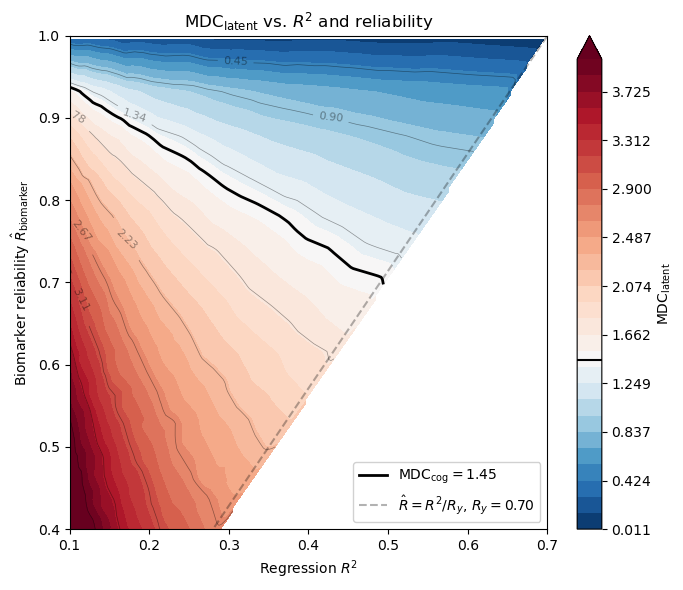

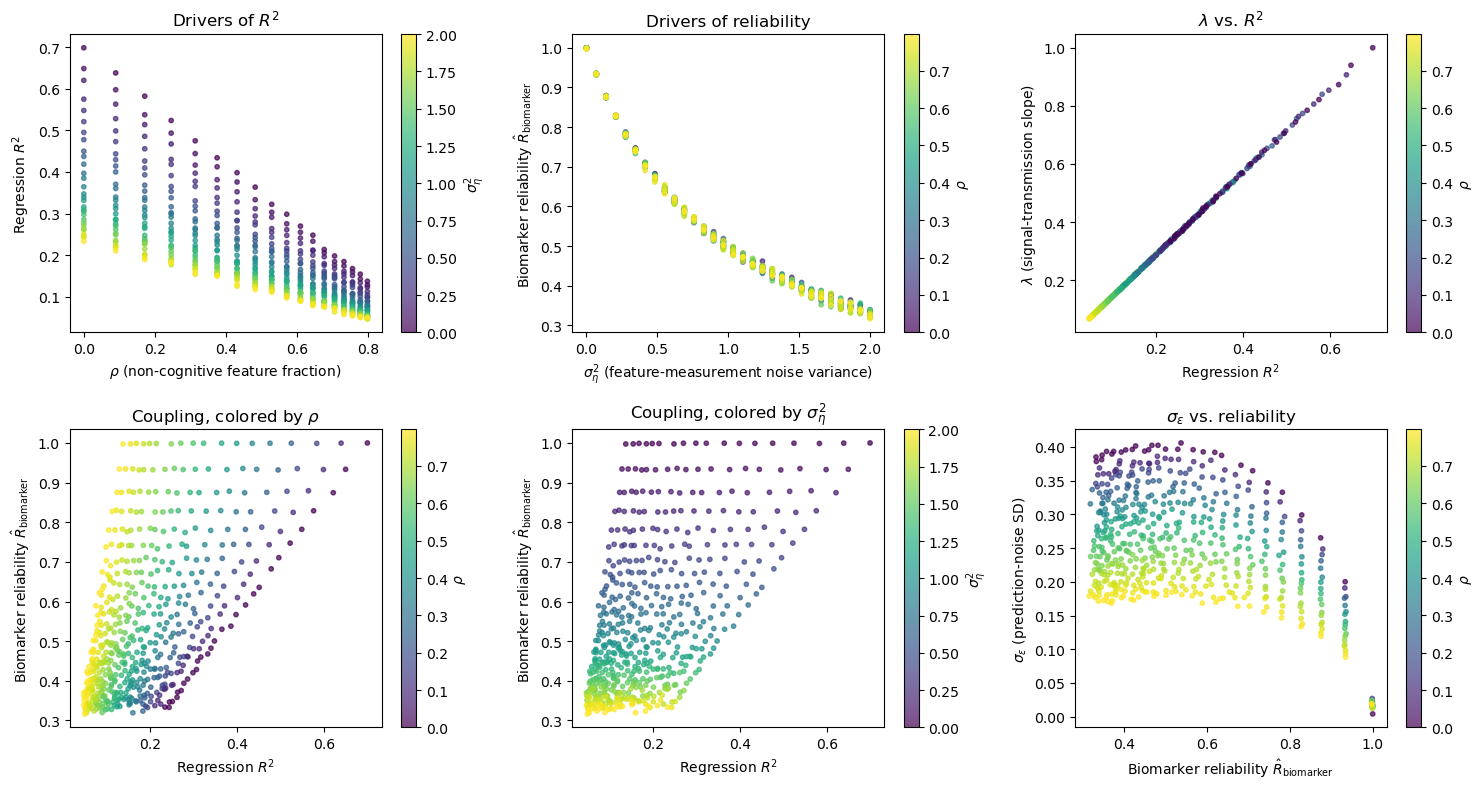

In [6]:
from scipy.interpolate import griddata
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ---------------------------------------------------------------
# Data prep
# ---------------------------------------------------------------
results_here = simulation_results.copy()
mdc_cognitive_mean = results_here['mdc_cognitive'].mean()

# ---------------------------------------------------------------
# Helper: lineplot with continuous colorbar
# ---------------------------------------------------------------
def _lineplot_with_cbar(fig, ax, data, x, y, hue, cmap='viridis', label=None):
    norm = Normalize(vmin=data[hue].min(), vmax=data[hue].max())
    sns.lineplot(
        data=data, x=x, y=y, hue=hue,
        palette=cmap, hue_norm=norm,
        legend=False, ax=ax,
    )
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label=label or hue)

# ---------------------------------------------------------------
# Helper: scatter with continuous colorbar
# ---------------------------------------------------------------
def _scatter_with_cbar(fig, ax, data, x, y, hue, cmap='viridis', label=None,
                       s=10, alpha=0.7):
    norm = Normalize(vmin=data[hue].min(), vmax=data[hue].max())
    sc = ax.scatter(
        data[x], data[y],
        c=data[hue], cmap=cmap, norm=norm,
        s=s, alpha=alpha,
    )
    fig.colorbar(sc, ax=ax, label=label or hue)

# ===============================================================
# FIGURE 1: Main decision plot
# ===============================================================
fig1, ax = plt.subplots(figsize=(7, 6))


x = results_here['regression_r2'].values
y = results_here['sample_biomarker_reliability'].values
z = results_here['mdc_latent_space'].values

xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)
Zi = griddata((x, y), z, (Xi, Yi), method='linear')

vmin = np.nanmin(Zi)
vmax = np.nanmax(Zi)
vmax_cap = 4.0  # cap the red end here
vcenter = np.clip(mdc_cognitive_mean, vmin + 1e-9, vmax_cap - 1e-9)
norm_mdc = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax_cap)

levels = np.linspace(vmin, vmax_cap, 30)
cf = ax.contourf(Xi, Yi, Zi, levels=levels, cmap='RdBu_r',
                 norm=norm_mdc, extend='max')

contour_levels = list(np.linspace(vmin, vmax_cap, 10)) + list(np.logspace(np.log10(vmax_cap), np.log10(vmax), 10))[1:]
ax.contour(Xi, Yi, Zi, levels=[vcenter], colors='black', linewidths=2)
cs = ax.contour(Xi, Yi, Zi, levels=contour_levels, colors='black', linewidths=0.5, alpha=0.4)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')

legend_handle = Line2D(
    [0], [0], color='black', linewidth=2,
    label=rf'$\mathrm{{MDC}}_{{\mathrm{{cog}}}} = {vcenter:.2f}$',
)


R_y = results_here['sample_target_reliability'].mean()
x_line = np.linspace(0, R_y, 100)
bound_line, = ax.plot(x_line, x_line / R_y, 'k--', lw=1.5, alpha=0.3,
                      label=fr'$\hat R = R^2 / R_y$, $R_y={R_y:.2f}$')


ax.legend(handles=[legend_handle, bound_line], loc='lower right', framealpha=0.9)

cbar = fig1.colorbar(cf, ax=ax, label=r'$\mathrm{MDC}_{\mathrm{latent}}$')
cbar.ax.axhline(vcenter, color='black', linewidth=1.5)

ax.set_xlabel(r'Regression $R^2$')
ax.set_ylabel(r'Biomarker reliability $\hat{R}_{\mathrm{biomarker}}$')
ax.set_title(r'$\mathrm{MDC}_{\mathrm{latent}}$ vs. $R^2$ and reliability')

ax.set_xlim(0.1, 0.7)
ax.set_ylim(0.4, 1)

plt.tight_layout()
plt.show()

# ===============================================================
# FIGURE 2: 3x2 grid of supporting analyses
# ===============================================================
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

features_measurement_noise_variance_limit = 2
rho_limit = 0.8
results_here_fig2 = results_here.query(f"features_measurement_noise_variance <= {features_measurement_noise_variance_limit} and rho <= {rho_limit}")

# --- [2a] R^2 drivers ------------------------------------------
ax = axes[0, 0]
_scatter_with_cbar(
    fig2, ax, results_here_fig2,
    x='rho', y='regression_r2',
    hue='features_measurement_noise_variance',
    label=r'$\sigma_\eta^2$',
)
ax.set_xlabel(r'$\rho$ (non-cognitive feature fraction)')
ax.set_ylabel(r'Regression $R^2$')
ax.set_title(r'Drivers of $R^2$')


# --- [2b] Reliability drivers ----------------------------------
ax = axes[0, 1]
_scatter_with_cbar(
    fig2, ax, results_here_fig2,
    x='features_measurement_noise_variance', y='sample_biomarker_reliability',
    hue='rho',
    label=r'$\rho$',
)
ax.set_xlabel(r'$\sigma_\eta^2$ (feature-measurement noise variance)')
ax.set_ylabel(r'Biomarker reliability $\hat{R}_{\mathrm{biomarker}}$')
ax.set_title(r'Drivers of reliability')

# --- [2c] lambda vs R^2 ----------------------------------------
ax = axes[0, 2]
_scatter_with_cbar(
    fig2, ax, results_here_fig2,
    x='regression_r2', y='lambda',
    hue='rho', label=r'$\rho$',
)
ax.set_xlabel(r'Regression $R^2$')
ax.set_ylabel(r'$\lambda$ (signal-transmission slope)')
ax.set_title(r'$\lambda$ vs. $R^2$')

# --- [2d] Coupling colored by rho ------------------------------
ax = axes[1, 0]
_scatter_with_cbar(
    fig2, ax, results_here_fig2,
    x='regression_r2', y='sample_biomarker_reliability',
    hue='rho', label=r'$\rho$',
)
ax.set_xlabel(r'Regression $R^2$')
ax.set_ylabel(r'Biomarker reliability $\hat{R}_{\mathrm{biomarker}}$')
ax.set_title(r'Coupling, colored by $\rho$')

# --- [2e] Coupling colored by sigma_eta^2 ----------------------
ax = axes[1, 1]
_scatter_with_cbar(
    fig2, ax, results_here_fig2,
    x='regression_r2', y='sample_biomarker_reliability',
    hue='features_measurement_noise_variance',
    label=r'$\sigma_\eta^2$',
)
ax.set_xlabel(r'Regression $R^2$')
ax.set_ylabel(r'Biomarker reliability $\hat{R}_{\mathrm{biomarker}}$')
ax.set_title(r'Coupling, colored by $\sigma_\eta^2$')


# --- [2f] sigma_epsilon vs reliability -------------------------
ax = axes[1, 2]
_scatter_with_cbar(
    fig2, ax, results_here_fig2,
    x='sample_biomarker_reliability', y='sigma_epsilon_hat',
    hue='rho',
    label=r'$\rho$',
)
ax.set_xlabel(r'Biomarker reliability $\hat{R}_{\mathrm{biomarker}}$')
ax.set_ylabel(r'$\sigma_\epsilon$ (prediction-noise SD)')
ax.set_title(r'$\sigma_\epsilon$ vs. reliability')

plt.tight_layout()
plt.show()


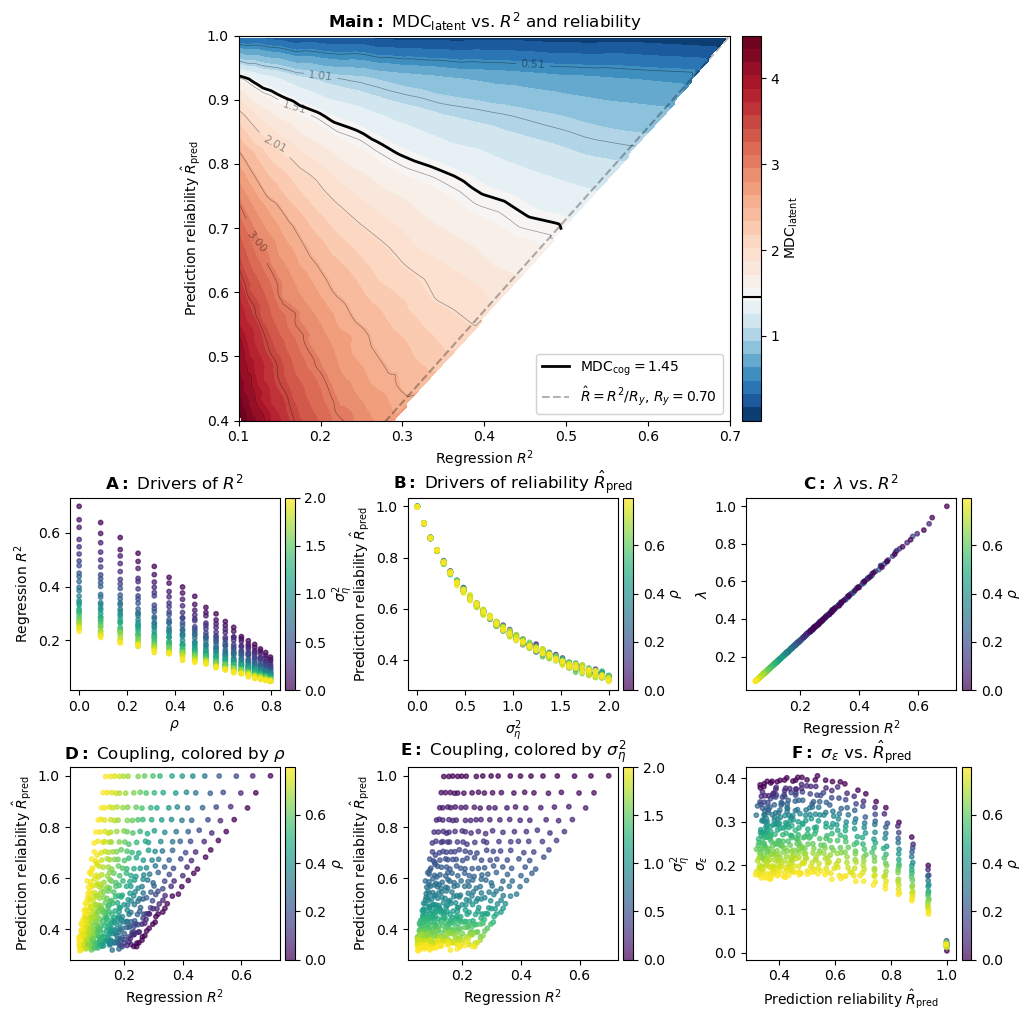

In [7]:

# ---------------------------------------------------------------
# Data prep
# ---------------------------------------------------------------
results_here = simulation_results.copy()
mdc_cognitive_mean = results_here['mdc_cognitive'].mean()

# ---------------------------------------------------------------
# Helper: lineplot with continuous colorbar
# ---------------------------------------------------------------
def _lineplot_with_cbar(fig, ax, data, x, y, hue, cmap='viridis', label=None):
    norm = Normalize(vmin=data[hue].min(), vmax=data[hue].max())
    sns.lineplot(
        data=data, x=x, y=y, hue=hue,
        palette=cmap, hue_norm=norm,
        legend=False, ax=ax,
    )
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label=label or hue)

# ---------------------------------------------------------------
# Helper: scatter with continuous colorbar
# ---------------------------------------------------------------
def _scatter_with_cbar(fig, ax, data, x, y, hue, cmap='viridis', label=None,
                       s=10, alpha=0.7):
    norm = Normalize(vmin=data[hue].min(), vmax=data[hue].max())
    sc = ax.scatter(
        data[x], data[y],
        c=data[hue], cmap=cmap, norm=norm,
        s=s, alpha=alpha,
    )
    fig.colorbar(sc, ax=ax, label=label or hue, pad=0.02)


# ===============================================================
# ONE FIGURE: primary plot left, 6 supporting plots right
# ===============================================================
with plt.rc_context({'axes.labelpad': 3}):
    fig = plt.figure(figsize=(12, 12))
    gs = fig.add_gridspec(
        nrows=3, ncols=6,
        #width_ratios=[1, 1, 1],
        height_ratios=[2, 1, 1],
        wspace=1, hspace=0.3
    )

    # Left primary subplot: spans full height
    ax_main = fig.add_subplot(gs[0, 1:5])

    # Right 6 subplots: 2 rows x 3 columns
    axes = np.array([
        [fig.add_subplot(gs[1, 0:2]), fig.add_subplot(gs[1, 2:4]), fig.add_subplot(gs[1, 4:6])],
        [fig.add_subplot(gs[2, 0:2]), fig.add_subplot(gs[2, 2:4]), fig.add_subplot(gs[2, 4:6])]
    ])


    # ===============================================================
    # PRIMARY PLOT
    # ===============================================================
    ax = ax_main

    x = results_here['regression_r2'].values
    y = results_here['sample_biomarker_reliability'].values
    z = results_here['mdc_latent_space'].values

    xi = np.linspace(x.min(), x.max(), 200)
    yi = np.linspace(y.min(), y.max(), 200)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), z, (Xi, Yi), method='linear')

    vmin = np.nanmin(Zi)
    vmax = np.nanmax(Zi)
    vmax_cap = 4.5
    vcenter = np.clip(mdc_cognitive_mean, vmin + 1e-9, vmax_cap - 1e-9)
    norm_mdc = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax_cap)

    levels = np.linspace(vmin, vmax_cap, 30)
    cf = ax.contourf(
        Xi, Yi, Zi,
        levels=levels,
        cmap='RdBu_r',
        norm=norm_mdc,
        #extend='max'
    )

    contour_levels = (
        list(np.linspace(vmin, vmax_cap, 10)) +
        list(np.logspace(np.log10(vmax_cap), np.log10(vmax), 10))[1:]
    )

    ax.contour(Xi, Yi, Zi, levels=[vcenter], colors='black', linewidths=2)
    cs = ax.contour(
        Xi, Yi, Zi,
        levels=contour_levels,
        colors='black',
        linewidths=0.5,
        alpha=0.4
    )
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')

    legend_handle = Line2D(
        [0], [0], color='black', linewidth=2,
        label=rf'$\mathrm{{MDC}}_{{\mathrm{{cog}}}} = {vcenter:.2f}$',
    )

    R_y = results_here['sample_target_reliability'].mean()
    x_line = np.linspace(0, R_y, 100)
    bound_line, = ax.plot(
        x_line, x_line / R_y,
        'k--', lw=1.5, alpha=0.3,
        label=fr'$\hat R = R^2 / R_y$, $R_y={R_y:.2f}$'
    )

    ax.legend(handles=[legend_handle, bound_line], loc='lower right', framealpha=0.9)

    cbar = fig.colorbar(cf, ax=ax, label=r'$\mathrm{MDC}_{\mathrm{latent}}$', pad=0.02)
    tick_min = int(np.ceil(vmin))
    tick_max = int(np.floor(vmax_cap))
    cbar.set_ticks(np.arange(tick_min, tick_max + 1, 1))
    cbar.ax.axhline(vcenter, color='black', linewidth=1.5)

    ax.set_xlabel(r'Regression $R^2$')
    ax.set_ylabel(r'Prediction reliability $\hat{R}_{\mathrm{pred}}$')
    ax.set_title(r'$\mathbf{Main:}$ $\mathrm{MDC}_{\mathrm{latent}}$ vs. $R^2$ and reliability')
    ax.set_xlim(0.1, 0.7)
    ax.set_ylim(0.4, 1)

    # ===============================================================
    # RIGHT-SIDE SUPPORTING PLOTS
    # ===============================================================
    features_measurement_noise_variance_limit = 2
    rho_limit = 0.8

    results_here_fig2 = results_here.query(
        f"features_measurement_noise_variance <= {features_measurement_noise_variance_limit} "
        f"and rho <= {rho_limit}"
    )

    # --- [2a] R^2 drivers ------------------------------------------
    ax = axes[0, 0]
    _scatter_with_cbar(
        fig, ax, results_here_fig2,
        x='rho', y='regression_r2',
        hue='features_measurement_noise_variance',
        label=r'$\sigma_\eta^2$',
    )
    ax.set_xlabel(r'$\rho$')
    ax.set_ylabel(r'Regression $R^2$')
    ax.set_title(r'$\mathbf{A:}$ Drivers of $R^2$')

    # --- [2b] Reliability drivers ----------------------------------
    ax = axes[0, 1]
    _scatter_with_cbar(
        fig, ax, results_here_fig2,
        x='features_measurement_noise_variance',
        y='sample_biomarker_reliability',
        hue='rho',
        label=r'$\rho$',
    )
    ax.set_xlabel(r'$\sigma_\eta^2$')
    ax.set_ylabel(r'Prediction reliability $\hat{R}_{\mathrm{pred}}$')
    ax.set_title(r'$\mathbf{B:}$ Drivers of reliability $\hat{R}_{\mathrm{pred}}$')

    # --- [2c] lambda vs R^2 ----------------------------------------
    ax = axes[0, 2]
    _scatter_with_cbar(
        fig, ax, results_here_fig2,
        x='regression_r2', y='lambda',
        hue='rho', label=r'$\rho$',
    )
    ax.set_xlabel(r'Regression $R^2$')
    ax.set_ylabel(r'$\lambda$')
    ax.set_title(r'$\mathbf{C:}$ $\lambda$ vs. $R^2$')

    # --- [2d] Coupling colored by rho ------------------------------
    ax = axes[1, 0]
    _scatter_with_cbar(
        fig, ax, results_here_fig2,
        x='regression_r2',
        y='sample_biomarker_reliability',
        hue='rho',
        label=r'$\rho$',
    )
    ax.set_xlabel(r'Regression $R^2$')
    ax.set_ylabel(r'Prediction reliability $\hat{R}_{\mathrm{pred}}$')
    ax.set_title(r'$\mathbf{D:}$ Coupling, colored by $\rho$')

    # --- [2e] Coupling colored by sigma_eta^2 ----------------------
    ax = axes[1, 1]
    _scatter_with_cbar(
        fig, ax, results_here_fig2,
        x='regression_r2',
        y='sample_biomarker_reliability',
        hue='features_measurement_noise_variance',
        label=r'$\sigma_\eta^2$',
    )
    ax.set_xlabel(r'Regression $R^2$')
    ax.set_ylabel(r'Prediction reliability $\hat{R}_{\mathrm{pred}}$')
    ax.set_title(r'$\mathbf{E:}$ Coupling, colored by $\sigma_\eta^2$')

    # --- [2f] sigma_epsilon vs reliability -------------------------
    ax = axes[1, 2]
    _scatter_with_cbar(
        fig, ax, results_here_fig2,
        x='sample_biomarker_reliability',
        y='sigma_epsilon_hat',
        hue='rho',
        label=r'$\rho$',
    )
    ax.set_xlabel(r'Prediction reliability $\hat{R}_{\mathrm{pred}}$')
    ax.set_ylabel(r'$\sigma_\epsilon$')
    ax.set_title(r'$\mathbf{F:}$ $\sigma_\epsilon$ vs. $\hat{R}_{\mathrm{pred}}$')

    #plt.tight_layout()
    plt.savefig("plots/simulation.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [1]:
# use as a function to estimate MDC from R2 / reliability
simulation_results[['regression_r2', 'sample_biomarker_reliability', 'mdc_latent_space']].to_parquet('mdc_points_for_estimator.parquet')

